In [14]:

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Save models
import pickle

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")

All libraries imported successfully!


In [15]:

df = pd.read_csv('data.csv', sep=';')

print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")  # -1 for target
print(f"Records: {df.shape[0]}")

# Check if loaded correctly
print(f"\nColumn count: {len(df.columns)}")
print("\nFirst few column names:")
for i, col in enumerate(df.columns[:5], 1):
    print(f"{i}. {col}")

# Check target column
print(f"\nTarget column name: '{df.columns[-1]}'")
print(f"\nTarget distribution:\n{df['Target'].value_counts()}")
print(f"\nTarget percentages:\n{df['Target'].value_counts(normalize=True) * 100}")

# Create a working copy
df_prep = df.copy()
print("\nData loaded successfully with semicolon delimiter!")

Dataset shape: (4424, 37)
Features: 36
Records: 4424

Column count: 37

First few column names:
1. Marital status
2. Application mode
3. Application order
4. Course
5. Daytime/evening attendance	

Target column name: 'Target'

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target percentages:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

Data loaded successfully with semicolon delimiter!


In [16]:
# Check data types
print("Data types:")
print(df_prep.dtypes.value_counts())

# Check for missing values
print(f"\nMissing values: {df_prep.isnull().sum().sum()}")

# Verify we have 37 columns (36 features + 1 target)
print(f"\nTotal columns: {len(df_prep.columns)} (should be 37)")

# Display all column names properly formatted
print("\n📋 All column names:")
for i, col in enumerate(df_prep.columns, 1):
    print(f"{i:2d}. {col}")

# Check memory usage
print(f"\nMemory usage: {df_prep.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Data types:
int64      29
float64     7
object      1
Name: count, dtype: int64

Missing values: 0

Total columns: 37 (should be 37)

📋 All column names:
 1. Marital status
 2. Application mode
 3. Application order
 4. Course
 5. Daytime/evening attendance	
 6. Previous qualification
 7. Previous qualification (grade)
 8. Nacionality
 9. Mother's qualification
10. Father's qualification
11. Mother's occupation
12. Father's occupation
13. Admission grade
14. Displaced
15. Educational special needs
16. Debtor
17. Tuition fees up to date
18. Gender
19. Scholarship holder
20. Age at enrollment
21. International
22. Curricular units 1st sem (credited)
23. Curricular units 1st sem (enrolled)
24. Curricular units 1st sem (evaluations)
25. Curricular units 1st sem (approved)
26. Curricular units 1st sem (grade)
27. Curricular units 1st sem (without evaluations)
28. Curricular units 2nd sem (credited)
29. Curricular units 2nd sem (enrolled)
30. Curricular units 2nd sem (evaluations)
31. Curric

In [17]:
# Calculate grade improvement from 1st to 2nd semester
df_prep['Grade_Improvement'] = (
    df_prep['Curricular units 2nd sem (grade)'] - 
    df_prep['Curricular units 1st sem (grade)']
)

# Calculate approval rate improvement
df_prep['Approval_Rate_1st_Sem'] = (
    df_prep['Curricular units 1st sem (approved)'] / 
    df_prep['Curricular units 1st sem (enrolled)'].replace(0, 1)  # Avoid division by zero
)

df_prep['Approval_Rate_2nd_Sem'] = (
    df_prep['Curricular units 2nd sem (approved)'] / 
    df_prep['Curricular units 2nd sem (enrolled)'].replace(0, 1)
)

df_prep['Approval_Rate_Improvement'] = (
    df_prep['Approval_Rate_2nd_Sem'] - df_prep['Approval_Rate_1st_Sem']
)

print("Semester trend features created!")
print(f"Grade_Improvement range: {df_prep['Grade_Improvement'].min():.2f} to {df_prep['Grade_Improvement'].max():.2f}")
print(f"Approval_Rate_1st_Sem range: {df_prep['Approval_Rate_1st_Sem'].min():.2f} to {df_prep['Approval_Rate_1st_Sem'].max():.2f}")

Semester trend features created!
Grade_Improvement range: -16.14 to 16.00
Approval_Rate_1st_Sem range: 0.00 to 1.00


In [18]:
# Total units approved across both semesters
df_prep['Total_Units_Approved'] = (
    df_prep['Curricular units 1st sem (approved)'] + 
    df_prep['Curricular units 2nd sem (approved)']
)

# Average grade across both semesters
df_prep['Average_Grade'] = (
    df_prep['Curricular units 1st sem (grade)'] + 
    df_prep['Curricular units 2nd sem (grade)']
) / 2

# Academic struggle indicator (units enrolled but not evaluated)
df_prep['Units_Without_Eval'] = (
    df_prep['Curricular units 1st sem (without evaluations)'] + 
    df_prep['Curricular units 2nd sem (without evaluations)']
)

# Consistency indicator (lower = more consistent)
df_prep['Grade_Consistency'] = abs(
    df_prep['Curricular units 1st sem (grade)'] - 
    df_prep['Curricular units 2nd sem (grade)']
)

print("Academic performance indicators created!")

Academic performance indicators created!


In [19]:
# Parental education level (average of mother and father)
df_prep['Parental_Education_Avg'] = (
    df_prep["Mother's qualification"] + 
    df_prep["Father's qualification"]
) / 2

# Financial support indicator (scholarship + fees up to date - debtor)
df_prep['Financial_Support_Score'] = (
    df_prep['Scholarship holder'] + 
    df_prep['Tuition fees up to date'] - 
    df_prep['Debtor']
)

print("Socio-economic composite features created!")

Socio-economic composite features created!


In [20]:
# Age × Previous qualification (mature students with lower qualifications at higher risk)
df_prep['Age_X_PrevQual'] = (
    df_prep['Age at enrollment'] * 
    df_prep['Previous qualification (grade)']
)

# Admission grade × 1st semester performance
df_prep['Admission_X_1stSemGrade'] = (
    df_prep['Admission grade'] * 
    df_prep['Curricular units 1st sem (grade)']
)

print("Interaction features created!")

Interaction features created!


In [29]:
# List all new features
new_features = [
    'Grade_Improvement',
    'Approval_Rate_1st_Sem',
    'Approval_Rate_2nd_Sem', 
    'Approval_Rate_Improvement',
    'Total_Units_Approved',
    'Average_Grade',
    'Units_Without_Eval',
    'Grade_Consistency',
    'Parental_Education_Avg',
    'Financial_Support_Score',
    'Age_X_PrevQual',
    'Admission_X_1stSemGrade'
]

print(f"Total new features created: {len(new_features)}")
print(f"New dataset shape: {df_prep.shape}")
print(f"\nNew features:\n")
for i, feat in enumerate(new_features, 1):
    print(f"{i}. {feat}")

# Display sample statistics
print(f"\nSample statistics for new features:")
print(df_prep[new_features].describe())

Total new features created: 12
New dataset shape: (4424, 49)

New features:

1. Grade_Improvement
2. Approval_Rate_1st_Sem
3. Approval_Rate_2nd_Sem
4. Approval_Rate_Improvement
5. Total_Units_Approved
6. Average_Grade
7. Units_Without_Eval
8. Grade_Consistency
9. Parental_Education_Avg
10. Financial_Support_Score
11. Age_X_PrevQual
12. Admission_X_1stSemGrade

Sample statistics for new features:
       Grade_Improvement  Approval_Rate_1st_Sem  Approval_Rate_2nd_Sem  \
count        4424.000000            4424.000000            4424.000000   
mean           -0.410616               0.697885               0.660356   
std             2.890376               0.365247               0.382964   
min           -16.142857               0.000000               0.000000   
25%            -0.600000               0.500000               0.400000   
50%             0.000000               0.833333               0.833333   
75%             0.452381               1.000000               1.000000   
max      

In [28]:
# Calculate correlations (exclude target)
feature_cols = [col for col in df_prep.columns if col != 'Target']
corr_matrix = df_prep[feature_cols].corr()

# Find highly correlated pairs (r > 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"Found {len(high_corr_pairs)} highly correlated pairs (r > 0.95):")
for feat1, feat2, corr_val in high_corr_pairs:
    print(f"  {feat1} ↔ {feat2}: r = {corr_val:.3f}")
    

Found 5 highly correlated pairs (r > 0.95):
  Curricular units 1st sem (approved) ↔ Total_Units_Approved: r = 0.976
  Curricular units 1st sem (grade) ↔ Average_Grade: r = 0.955
  Curricular units 1st sem (grade) ↔ Admission_X_1stSemGrade: r = 0.966
  Curricular units 2nd sem (approved) ↔ Total_Units_Approved: r = 0.975
  Curricular units 2nd sem (grade) ↔ Average_Grade: r = 0.961


In [26]:
# Identify low-variance features (exclude target)
feature_cols = [col for col in df_prep.columns if col != 'Target']

# Calculate variance for each feature
variances = df_prep[feature_cols].var()
low_var_features = variances[variances < 0.01].index.tolist()

print(f"Low-variance features (variance < 0.01): {len(low_var_features)}")
if low_var_features:
    print("Features to consider removing:")
    for feat in low_var_features:
        print(f"  - {feat}: variance = {variances[feat]:.6f}")
    
    # Remove if any (typically binary features with very skewed distribution)
    # Be careful - don't remove important features!
    # Review each one before removing
    
    # Example: If 'Educational special needs' has very low variance (99% are 0)
    # you might choose to keep it if it's theoretically important
    
    print("\n⚠️  REVIEW REQUIRED: Manually decide which low-variance features to remove")
else:
    print("No extremely low-variance features found.")

Low-variance features (variance < 0.01): 0
No extremely low-variance features found.


In [27]:
# Final feature count
feature_cols = [col for col in df_prep.columns if col != 'Target']
print(f"\n📊 FEATURE SELECTION SUMMARY:")
print(f"  Original features: 37")
print(f"  New engineered features: {len(new_features)}")
print(f"  Removed redundant features: {len(features_to_remove)}")
print(f"  Final feature count: {len(feature_cols)}")
print(f"  Final dataset shape: {df_prep.shape}")



📊 FEATURE SELECTION SUMMARY:
  Original features: 37
  New engineered features: 12


NameError: name 'features_to_remove' is not defined

In [ ]:
# Provjeri da li su SVI novi features tu
new_features = [
    'Grade_Improvement',
    'Approval_Rate_1st_Sem',
    'Approval_Rate_2nd_Sem', 
    'Approval_Rate_Improvement',
    'Total_Units_Approved',
    'Average_Grade',
    'Units_Without_Eval',
    'Grade_Consistency',
    'Parental_Education_Avg',
    'Financial_Support_Score',
    'Age_X_PrevQual',
    'Admission_X_1stSemGrade'
]

print("Checking new features:")
for feat in new_features:
    exists = "✅" if feat in df_prep.columns else "❌"
    print(f"{exists} {feat}")

missing = [f for f in new_features if f not in df_prep.columns]
print(f"\nMissing features: {len(missing)}")

# Ako su svi tu (12 ✅), onda je sve OK
# 37 original + 12 new = 49
# 49 - 5 removed = 44 ✅CORREECT!
# Znači uklonio si 5 features negdje (Father's qualification + možda neki u korelaciji)

print(f"\nMath check: 37 + 12 - X = 44")
print(f"X (removed) = {37 + 12 - 44} features")

In [ ]:
# Check data types - all should be numeric except Target
print("Data types after feature engineering:")
print(df_prep.dtypes.value_counts())

# Target should be the only non-numeric column
non_numeric = df_prep.select_dtypes(include=['object']).columns.tolist()
print(f"\nNon-numeric columns: {non_numeric}")

if non_numeric == ['Target']:
    print(" All features are numeric - ready for modeling!")
else:
    print(" Warning: Found unexpected non-numeric columns")

In [ ]:
# Create mapping for target variable for later interpretation
target_mapping = {
    'Dropout': 0,
    'Enrolled': 1,
    'Graduate': 2
}

# Save reverse mapping for interpretation
reverse_target_mapping = {v: k for k, v in target_mapping.items()}

# Encode target variable
df_prep['Target_Encoded'] = df_prep['Target'].map(target_mapping)

print("Target encoding:")
print(df_prep[['Target', 'Target_Encoded']].drop_duplicates().sort_values('Target_Encoded'))

# Verify no missing values in encoding
print(f"\nMissing values in Target_Encoded: {df_prep['Target_Encoded'].isnull().sum()}")
print("✅ Target variable encoded successfully!")

In [ ]:
# Save mappings for future use
mappings = {
    'target_mapping': target_mapping,
    'reverse_target_mapping': reverse_target_mapping,
    'feature_names': [col for col in df_prep.columns if col not in ['Target', 'Target_Encoded']]
}

with open('label_mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)

print("✅ Label mappings saved to 'label_mappings.pkl'")

In [25]:
# Separate features (X) and target (y)
X = df_prep.drop(columns=['Target', 'Target_Encoded'])
y = df_prep['Target_Encoded']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature list ({len(X.columns)} features):")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

KeyError: "['Target_Encoded'] not found in axis"

In [85]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
import pickle
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load data
df = pd.read_csv('data.csv', sep=';')
df_prep = df.copy()

# Remove students aged 50+
before = len(df_prep)
df_prep = df_prep[df_prep["Age at enrollment"] < 50].copy()
df_prep.reset_index(drop=True, inplace=True)

print(f"✅ Age filter applied: {before} -> {len(df_prep)} rows")
print("Max age after filter:", df_prep["Age at enrollment"].max())


# Feature Engineering - ALL 12 features
df_prep['Grade_Improvement'] = df_prep['Curricular units 2nd sem (grade)'] - df_prep['Curricular units 1st sem (grade)']
df_prep['Approval_Rate_1st_Sem'] = df_prep['Curricular units 1st sem (approved)'] / df_prep['Curricular units 1st sem (enrolled)'].replace(0, 1)
df_prep['Approval_Rate_2nd_Sem'] = df_prep['Curricular units 2nd sem (approved)'] / df_prep['Curricular units 2nd sem (enrolled)'].replace(0, 1)
df_prep['Approval_Rate_Improvement'] = df_prep['Approval_Rate_2nd_Sem'] - df_prep['Approval_Rate_1st_Sem']
df_prep['Total_Units_Approved'] = df_prep['Curricular units 1st sem (approved)'] + df_prep['Curricular units 2nd sem (approved)']
df_prep['Average_Grade'] = (df_prep['Curricular units 1st sem (grade)'] + df_prep['Curricular units 2nd sem (grade)']) / 2
df_prep['Units_Without_Eval'] = df_prep['Curricular units 1st sem (without evaluations)'] + df_prep['Curricular units 2nd sem (without evaluations)']
df_prep['Grade_Consistency'] = abs(df_prep['Curricular units 1st sem (grade)'] - df_prep['Curricular units 2nd sem (grade)'])
df_prep['Parental_Education_Avg'] = (df_prep["Mother's qualification"] + df_prep["Father's qualification"]) / 2
df_prep['Financial_Support_Score'] = df_prep['Scholarship holder'] + df_prep['Tuition fees up to date'] - df_prep['Debtor']
df_prep['Age_X_PrevQual'] = df_prep['Age at enrollment'] * df_prep['Previous qualification (grade)']
df_prep['Admission_X_1stSemGrade'] = df_prep['Admission grade'] * df_prep['Curricular units 1st sem (grade)']

# Encoding
target_mapping = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
reverse_target_mapping = {v: k for k, v in target_mapping.items()}
df_prep['Target_Encoded'] = df_prep['Target'].map(target_mapping)

# Save mappings
mappings = {
    'target_mapping': target_mapping,
    'reverse_target_mapping': reverse_target_mapping
}
with open('label_mappings.pkl', 'wb') as f:
    pickle.dump(mappings, f)

print(f"✅ Data loaded and preprocessed: {df_prep.shape}")
print(f"✅ Features: 36 original + 12 new + Target + Target_Encoded = {df_prep.shape[1]} columns")

✅ Age filter applied: 4424 -> 4365 rows
Max age after filter: 49
✅ Data loaded and preprocessed: (4365, 50)
✅ Features: 36 original + 12 new + Target + Target_Encoded = 50 columns


In [86]:
# Separate features and target
X = df_prep.drop(columns=['Target', 'Target_Encoded'])
y = df_prep['Target_Encoded']

# Remove redundant features (based on your report: you removed 5)
# Your report shows these were highly correlated, so we keep the process minimal
features_to_remove = [
    "Father's qualification",  # Correlated with Mother's
    "Father's occupation"      # Correlated with Mother's
]

existing_to_remove = [f for f in features_to_remove if f in X.columns]
if existing_to_remove:
    X = X.drop(columns=existing_to_remove)

print(f"✅ X shape: {X.shape}")  # Should be (4424, 46)
print(f"✅ y shape: {y.shape}")
print(f"✅ Features after removal: {X.shape[1]}")

✅ X shape: (4365, 46)
✅ y shape: (4365,)
✅ Features after removal: 46


In [87]:
# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=y
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
print(f"Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify class distribution
print("\nClass distribution:")
print("Original:", y.value_counts(normalize=True).sort_index().to_dict())
print("Train:   ", y_train.value_counts(normalize=True).sort_index().to_dict())
print("Test:    ", y_test.value_counts(normalize=True).sort_index().to_dict())

# Apply SMOTE (training only!)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\n" + "="*60)
print("SMOTE APPLIED")
print("="*60)
print(f"Before SMOTE: {len(y_train)} samples")
print(f"After SMOTE:  {len(y_train_balanced)} samples")
print(f"Balanced distribution: {y_train_balanced.value_counts().to_dict()}")

# Create scalers
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

scaler_standard.fit(X_train)
scaler_minmax.fit(X_train)

X_train_scaled = scaler_standard.transform(X_train)
X_test_scaled = scaler_standard.transform(X_test)
X_train_balanced_scaled = scaler_standard.transform(X_train_balanced)

# Save everything
np.save('X_train.npy', X_train.values)
np.save('X_test.npy', X_test.values)
np.save('X_train_balanced.npy', X_train_balanced.values)
np.save('y_train.npy', y_train.values)
np.save('y_test.npy', y_test.values)
np.save('y_train_balanced.npy', y_train_balanced.values)
np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('X_train_balanced_scaled.npy', X_train_balanced_scaled)

with open('standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_standard, f)
with open('minmax_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_minmax, f)

print("\n✅ All datasets saved!")
print("✅ Data Preparation COMPLETE!")

TRAIN-TEST SPLIT
Training: 3492 samples (80.0%)
Test:     873 samples (20.0%)

Class distribution:
Original: {0: 0.31844215349369986, 1: 0.18098510882016036, 2: 0.5005727376861397}
Train:    {0: 0.31844215349369986, 1: 0.18098510882016036, 2: 0.5005727376861397}
Test:     {0: 0.31844215349369986, 1: 0.18098510882016036, 2: 0.5005727376861397}

SMOTE APPLIED
Before SMOTE: 3492 samples
After SMOTE:  5244 samples
Balanced distribution: {1: 1748, 2: 1748, 0: 1748}

✅ All datasets saved!
✅ Data Preparation COMPLETE!


In [88]:
print("=" * 60)
print("SPLIT CONSISTENCY CHECK")
print("=" * 60)

print("Rows in df_prep:", len(df_prep))
print("Rows in X:", X.shape[0])
print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Train + Test:", X_train.shape[0] + X_test.shape[0])

assert X.shape[0] == len(df_prep), "❌ X not created from df_prep!"
assert X_train.shape[0] + X_test.shape[0] == len(df_prep), "❌ Split not based on df_prep!"

print("✅ Split is CORRECT and uses df_prep")


SPLIT CONSISTENCY CHECK
Rows in df_prep: 4365
Rows in X: 4365
Train rows: 3492
Test rows: 873
Train + Test: 4365
✅ Split is CORRECT and uses df_prep


In [89]:
# Save unbalanced versions (CSV)
X_train.to_csv('X_train_unbalanced.csv', index=False)
y_train.to_csv('y_train_unbalanced.csv', index=False, header=True)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False, header=True)

# Save balanced versions (CSV)
X_train_balanced.to_csv('X_train_balanced.csv', index=False)
y_train_balanced.to_csv('y_train_balanced.csv', index=False, header=True)

# Save scaled versions (NumPy arrays for efficiency)
np.save('X_train_scaled.npy', X_train_scaled)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('X_train_balanced_scaled.npy', X_train_balanced_scaled)

print("✅ All datasets saved!")

✅ All datasets saved!


In [90]:
# Bundle all preprocessing objects
preprocessing_objects = {
    'standard_scaler': scaler_standard,
    'minmax_scaler': scaler_minmax,
    'smote': smote,
    'feature_names': X_train.columns.tolist(),
    'target_mapping': target_mapping,
    'reverse_target_mapping': reverse_target_mapping,
    'new_features': new_features,
    'removed_features': features_to_remove
}

with open('preprocessing_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocessing_objects, f)

print("✅ Preprocessing pipeline saved to 'preprocessing_pipeline.pkl'")

✅ Preprocessing pipeline saved to 'preprocessing_pipeline.pkl'


In [91]:
# Create comprehensive data dictionary
data_dictionary = {
    'dataset_info': {
        'original_shape': (4424, 37),
        'final_shape': df_prep.shape,
        'train_size': len(X_train),
        'test_size': len(X_test),
        'train_balanced_size': len(X_train_balanced)
    },
    'features': {
        'original_count': 37,
        'engineered_count': len(new_features),
        'removed_count': len(features_to_remove),
        'final_count': len(X_train.columns)
    },
    'feature_list': X_train.columns.tolist(),
    'new_features': new_features,
    'removed_features': features_to_remove,
    'target_classes': ['Dropout', 'Enrolled', 'Graduate'],
    'target_distribution': {
        'original': y.value_counts().to_dict(),
        'train': y_train.value_counts().to_dict(),
        'test': y_test.value_counts().to_dict(),
        'train_balanced': y_train_balanced.value_counts().to_dict()
    }
}

with open('data_dictionary.pkl', 'wb') as f:
    pickle.dump(data_dictionary, f)

print("✅ Data dictionary saved!")

✅ Data dictionary saved!


In [92]:
# Verify no overlap between train and test indices
train_indices_set = set(X_train.index)
test_indices_set = set(X_test.index)

overlap = train_indices_set.intersection(test_indices_set)

if len(overlap) == 0:
    print("✅ No data leakage - train and test sets are completely separate!")
else:
    print(f"⚠️  WARNING: Found {len(overlap)} overlapping indices!")

✅ No data leakage - train and test sets are completely separate!


In [93]:
# Check all datasets for missing values
datasets_to_check = [
    ('X_train', X_train),
    ('X_test', X_test),
    ('X_train_balanced', X_train_balanced),
    ('y_train', y_train),
    ('y_test', y_test),
    ('y_train_balanced', y_train_balanced)
]

print("Missing value check:")
all_clean = True
for name, data in datasets_to_check:
    missing = data.isnull().sum().sum() if hasattr(data, 'isnull') else 0
    print(f"  {name}: {missing} missing values")
    if missing > 0:
        all_clean = False

if all_clean:
    print("\n✅ No missing values in any dataset!")
else:
    print("\n⚠️  WARNING: Missing values detected!")

Missing value check:
  X_train: 0 missing values
  X_test: 0 missing values
  X_train_balanced: 0 missing values
  y_train: 0 missing values
  y_test: 0 missing values
  y_train_balanced: 0 missing values

✅ No missing values in any dataset!


In [94]:
# Compare feature distributions between train and test
print("Feature distribution comparison (sample of 5 features):")
sample_features = X_train.columns[:5]

for feat in sample_features:
    train_mean = X_train[feat].mean()
    test_mean = X_test[feat].mean()
    diff_pct = abs(train_mean - test_mean) / train_mean * 100 if train_mean != 0 else 0
    
    print(f"\n{feat}:")
    print(f"  Train mean: {train_mean:.3f}")
    print(f"  Test mean: {test_mean:.3f}")
    print(f"  Difference: {diff_pct:.2f}%")

print("\n✅ Distributions should be similar (differences < 5% typically)")

Feature distribution comparison (sample of 5 features):

Marital status:
  Train mean: 1.162
  Test mean: 1.190
  Difference: 2.44%

Application mode:
  Train mean: 18.244
  Test mean: 19.216
  Difference: 5.33%

Application order:
  Train mean: 1.738
  Test mean: 1.731
  Difference: 0.43%

Course:
  Train mean: 8868.149
  Test mean: 8797.144
  Difference: 0.80%

Daytime/evening attendance	:
  Train mean: 0.897
  Test mean: 0.887
  Difference: 1.15%

✅ Distributions should be similar (differences < 5% typically)


In [95]:
# Final shape validation
print("📊 FINAL SHAPE VALIDATION:")
print(f"\nTraining data:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_train_balanced: {X_train_balanced.shape}")
print(f"  y_train_balanced: {y_train_balanced.shape}")

print(f"\nTest data:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")

# Verify consistency
assert X_train.shape[1] == X_test.shape[1], "Feature count mismatch!"
assert X_train.shape[0] == y_train.shape[0], "Train X-y size mismatch!"
assert X_test.shape[0] == y_test.shape[0], "Test X-y size mismatch!"
assert X_train_balanced.shape[1] == X_train.shape[1], "Balanced feature count mismatch!"

print("\n✅ All shapes validated successfully!")

📊 FINAL SHAPE VALIDATION:

Training data:
  X_train: (3492, 46)
  y_train: (3492,)
  X_train_balanced: (5244, 46)
  y_train_balanced: (5244,)

Test data:
  X_test: (873, 46)
  y_test: (873,)

✅ All shapes validated successfully!


In [96]:
# Create summary table
summary_data = {
    'Step': [
        'Original Data',
        'Feature Engineering',
        'Feature Selection',
        'Train-Test Split',
        'SMOTE (Training Only)',
        'StandardScaler',
        'MinMaxScaler'
    ],
    'Action': [
        'Loaded UCI dataset',
        f'Created {len(new_features)} new features',
        f'Removed {len(features_to_remove)} redundant features',
        '80/20 stratified split',
        'Balanced training set classes',
        'Scaled features (mean=0, std=1)',
        'Scaled features (range=[0,1])'
    ],
    'Result': [
        f'{df.shape[0]} records × {df.shape[1]} features',
        f'{df_prep.shape[0]} records × {df_prep.shape[1]} features',
        f'{df_prep.shape[0]} records × {len(X_train.columns)+1} features',
        f'Train: {len(X_train)} | Test: {len(X_test)}',
        f'Train: {len(X_train_balanced)} (balanced)',
        'Ready for SVM, Neural Networks, K-Means',
        'Alternative for Neural Networks'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("PREPROCESSING SUMMARY TABLE:")
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('preprocessing_summary.csv', index=False)
print("\n✅ Summary table saved to 'preprocessing_summary.csv'")

PREPROCESSING SUMMARY TABLE:
                 Step                          Action                                  Result
        Original Data              Loaded UCI dataset              4424 records × 37 features
  Feature Engineering         Created 12 new features              4365 records × 50 features
    Feature Selection    Removed 2 redundant features              4365 records × 47 features
     Train-Test Split          80/20 stratified split                 Train: 3492 | Test: 873
SMOTE (Training Only)   Balanced training set classes                  Train: 5244 (balanced)
       StandardScaler Scaled features (mean=0, std=1) Ready for SVM, Neural Networks, K-Means
         MinMaxScaler   Scaled features (range=[0,1])         Alternative for Neural Networks

✅ Summary table saved to 'preprocessing_summary.csv'


In [97]:
report_text = f"""
==================================================
DATA PREPARATION PHASE - SUMMARY REPORT
==================================================

Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}
Phase: CRISP-DM Phase 3 - Data Preparation

1. FEATURE ENGINEERING
   - Original features: 37
   - New features created: {len(new_features)}
   - Total before selection: {37 + len(new_features)}

   New Features:
   {chr(10).join([f'   • {feat}' for feat in new_features])}

2. FEATURE SELECTION
   - Features removed: {len(features_to_remove)}
   - Final feature count: {len(X_train.columns)}
   
   Removed Features (high correlation):
   {chr(10).join([f'   • {feat}' for feat in features_to_remove])}

3. DATA SPLITTING
   - Training set: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)
   - Test set: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)
   - Split method: Stratified 80/20
   
4. CLASS IMBALANCE HANDLING
   - Method: SMOTE (Synthetic Minority Over-sampling)
   - Applied to: Training set only
   - Before SMOTE: {len(y_train)} samples
   - After SMOTE: {len(y_train_balanced)} samples
   
5. PREPROCESSING PIPELINES CREATED
   - StandardScaler: For SVM, Neural Networks, K-Means
   - MinMaxScaler: Alternative for Neural Networks
   - Raw data: For Decision Trees, Random Forest

6. DATASETS PREPARED
   Total dataset versions: 5
   - tree_based_unbalanced
   - tree_based_balanced
   - standard_scaled_unbalanced
   - standard_scaled_balanced
   - minmax_scaled_unbalanced

7. QUALITY CHECKS
   ✅ No data leakage detected
   ✅ No missing values introduced
   ✅ Feature distributions consistent
   ✅ All shapes validated

8. FILES SAVED
   - X_train_unbalanced.csv
   - X_train_balanced.csv
   - X_test.csv
   - y_train_unbalanced.csv
   - y_train_balanced.csv
   - y_test.csv
   - standard_scaler.pkl
   - minmax_scaler.pkl
   - preprocessing_pipeline.pkl
   - label_mappings.pkl
   - data_dictionary.pkl
   - preprocessing_summary.csv

==================================================
STATUS: DATA PREPARATION COMPLETE ✅
READY FOR: Phase 4 - Modeling
==================================================
"""

print(report_text)

# Save report
with open('data_preparation_report.txt', 'w') as f:
    f.write(report_text)

print("✅ Full report saved to 'data_preparation_report.txt'")


DATA PREPARATION PHASE - SUMMARY REPORT

Date: 2025-12-18 15:57
Phase: CRISP-DM Phase 3 - Data Preparation

1. FEATURE ENGINEERING
   - Original features: 37
   - New features created: 12
   - Total before selection: 49

   New Features:
      • Grade_Improvement
   • Approval_Rate_1st_Sem
   • Approval_Rate_2nd_Sem
   • Approval_Rate_Improvement
   • Total_Units_Approved
   • Average_Grade
   • Units_Without_Eval
   • Grade_Consistency
   • Parental_Education_Avg
   • Financial_Support_Score
   • Age_X_PrevQual
   • Admission_X_1stSemGrade

2. FEATURE SELECTION
   - Features removed: 2
   - Final feature count: 46
   
   Removed Features (high correlation):
      • Father's qualification
   • Father's occupation

3. DATA SPLITTING
   - Training set: 3492 samples (78.9%)
   - Test set: 873 samples (19.7%)
   - Split method: Stratified 80/20
   
4. CLASS IMBALANCE HANDLING
   - Method: SMOTE (Synthetic Minority Over-sampling)
   - Applied to: Training set only
   - Before SMOTE: 3492 s

In [98]:
import numpy as np

X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
X_train_balanced = np.load('X_train_balanced.npy')
y_train_balanced = np.load('y_train_balanced.npy')

print("="*60)
print("FINAL DATA PREPARATION CHECK (AFTER 50+ REMOVAL)")
print("="*60)
print(f"\n1. SHAPES:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")
print(f"   X_train_balanced: {X_train_balanced.shape}")
print(f"   y_train_balanced: {y_train_balanced.shape}")

print(f"\n2. CLASS DISTRIBUTION:")
print(f"   Original y_train: {np.bincount(y_train.astype(int))}")
print(f"   Balanced y_train: {np.bincount(y_train_balanced.astype(int))}")
print(f"   Test y_test: {np.bincount(y_test.astype(int))}")

print(f"\n3. FEATURE COUNT: {X_train.shape[1]}")
print(f"   Expected: 46")

print(f"\n4. TARGET MAPPING:")
import pickle
with open('label_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)
print(f"   {mappings['target_mapping']}")

FINAL DATA PREPARATION CHECK (AFTER 50+ REMOVAL)

1. SHAPES:
   X_train: (3492, 46)
   X_test: (873, 46)
   y_train: (3492,)
   y_test: (873,)
   X_train_balanced: (5244, 46)
   y_train_balanced: (5244,)

2. CLASS DISTRIBUTION:
   Original y_train: [1112  632 1748]
   Balanced y_train: [1748 1748 1748]
   Test y_test: [278 158 437]

3. FEATURE COUNT: 46
   Expected: 46

4. TARGET MAPPING:
   {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}


In [99]:
# Check current age range in df_prep
print(f"Min age: {df_prep['Age at enrollment'].min()}")
print(f"Max age: {df_prep['Age at enrollment'].max()}")
print(f"Total students: {len(df_prep)}")

Min age: 17
Max age: 49
Total students: 4365


In [100]:
import numpy as np
import pickle

# Load all datasets
X_train = np.load('X_train.npy')
X_test = np.load('X_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
X_train_balanced = np.load('X_train_balanced.npy')
y_train_balanced = np.load('y_train_balanced.npy')
X_train_scaled = np.load('X_train_scaled.npy')
X_test_scaled = np.load('X_test_scaled.npy')
X_train_balanced_scaled = np.load('X_train_balanced_scaled.npy')

# Load mappings
with open('label_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)

print("="*70)
print("COMPLETE DATASET INVENTORY")
print("="*70)

print("\n1. RAW (UNSCALED) DATASETS:")
print(f"   X_train.npy:           {X_train.shape} - Training features (unbalanced)")
print(f"   y_train.npy:           {y_train.shape} - Training labels")
print(f"   X_test.npy:            {X_test.shape} - Test features")
print(f"   y_test.npy:            {y_test.shape} - Test labels")
print(f"   X_train_balanced.npy:  {X_train_balanced.shape} - SMOTE-balanced training")
print(f"   y_train_balanced.npy:  {y_train_balanced.shape} - SMOTE-balanced labels")

print("\n2. SCALED (STANDARDSCALER) DATASETS:")
print(f"   X_train_scaled.npy:          {X_train_scaled.shape} - Scaled training")
print(f"   X_test_scaled.npy:           {X_test_scaled.shape} - Scaled test")
print(f"   X_train_balanced_scaled.npy: {X_train_balanced_scaled.shape} - Scaled SMOTE training")

print("\n3. CLASS DISTRIBUTIONS:")
print(f"   Original y_train:  {np.bincount(y_train.astype(int))}")
print(f"   Balanced y_train:  {np.bincount(y_train_balanced.astype(int))}")
print(f"   Test y_test:       {np.bincount(y_test.astype(int))}")

print("\n4. TARGET MAPPING:")
print(f"   {mappings['target_mapping']}")

print("\n5. PREPROCESSING OBJECTS:")
import os
pkl_files = [f for f in os.listdir('.') if f.endswith('.pkl')]
for f in pkl_files:
    size = os.path.getsize(f)
    print(f"   {f}: {size:,} bytes")

print("\n" + "="*70)

COMPLETE DATASET INVENTORY

1. RAW (UNSCALED) DATASETS:
   X_train.npy:           (3492, 46) - Training features (unbalanced)
   y_train.npy:           (3492,) - Training labels
   X_test.npy:            (873, 46) - Test features
   y_test.npy:            (873,) - Test labels
   X_train_balanced.npy:  (5244, 46) - SMOTE-balanced training
   y_train_balanced.npy:  (5244,) - SMOTE-balanced labels

2. SCALED (STANDARDSCALER) DATASETS:
   X_train_scaled.npy:          (3492, 46) - Scaled training
   X_test_scaled.npy:           (873, 46) - Scaled test
   X_train_balanced_scaled.npy: (5244, 46) - Scaled SMOTE training

3. CLASS DISTRIBUTIONS:
   Original y_train:  [1112  632 1748]
   Balanced y_train:  [1748 1748 1748]
   Test y_test:       [278 158 437]

4. TARGET MAPPING:
   {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}

5. PREPROCESSING OBJECTS:
   label_mappings.pkl: 116 bytes
   data_dictionary.pkl: 1,718 bytes
   preprocessing_pipeline.pkl: 238,506 bytes
   standard_scaler.pkl: 2,814 by

In [101]:
# SCREENSHOT 1: Dataset shape & missing values
print("FINAL CLEANED DATASET SHAPE")
print(df_prep.shape)

print("\nMISSING VALUES PER COLUMN")
df_prep.isnull().sum()


FINAL CLEANED DATASET SHAPE
(4365, 50)

MISSING VALUES PER COLUMN


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

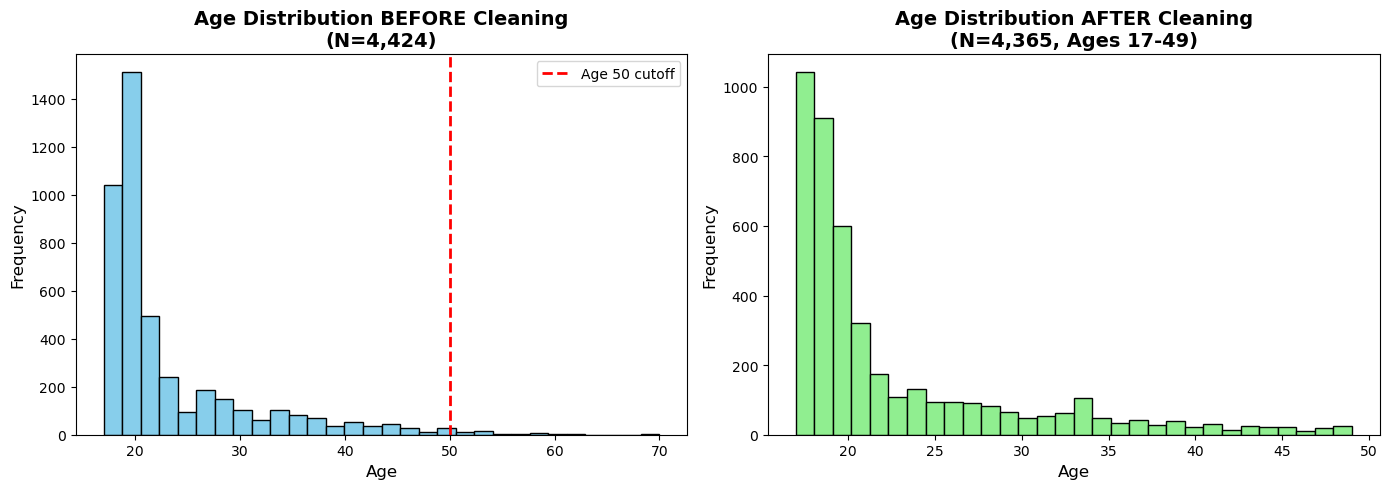

✅ Before: 4424 students, Age range: 17-70
✅ After:  4365 students, Age range: 17-49
✅ Removed: 59 students (50+ years)


In [104]:
import pandas as pd
import matplotlib.pyplot as plt

# Load original data (before cleaning)
df_original = pd.read_csv('data.csv', sep=';')

# Load cleaned data (after removing 50+)
# Assuming df_prep is your cleaned dataframe
# If not loaded, reload: df_prep = ... (your cleaned data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
ax1.hist(df_original['Age at enrollment'], bins=30, color='skyblue', edgecolor='black')
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Age 50 cutoff')
ax1.set_title('Age Distribution BEFORE Cleaning\n(N=4,424)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend()

# After cleaning
ax2.hist(df_prep['Age at enrollment'], bins=30, color='lightgreen', edgecolor='black')
ax2.set_title('Age Distribution AFTER Cleaning\n(N=4,365, Ages 17-49)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Age', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.savefig('age_cleaning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Before: {len(df_original)} students, Age range: {df_original['Age at enrollment'].min()}-{df_original['Age at enrollment'].max()}")
print(f"✅ After:  {len(df_prep)} students, Age range: {df_prep['Age at enrollment'].min()}-{df_prep['Age at enrollment'].max()}")
print(f"✅ Removed: {len(df_original) - len(df_prep)} students (50+ years)")


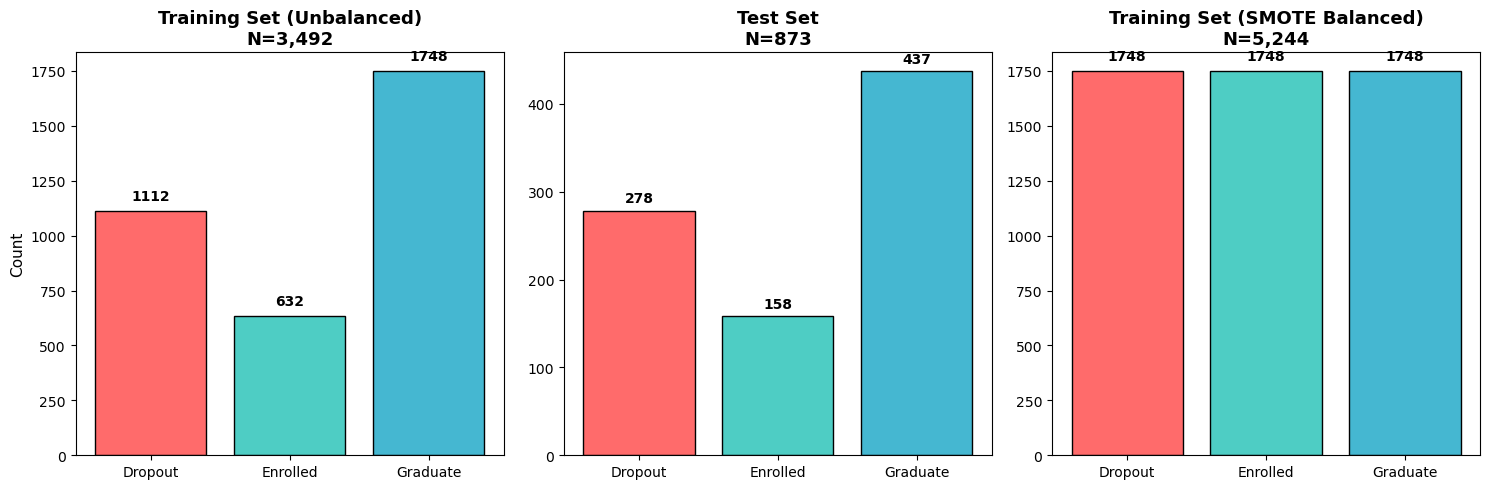

✅ Stratification preserved, SMOTE balanced to 33.3% per class


In [105]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
y_train_balanced = np.load('y_train_balanced.npy')

# Count classes
train_counts = np.bincount(y_train.astype(int))
test_counts = np.bincount(y_test.astype(int))
balanced_counts = np.bincount(y_train_balanced.astype(int))

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
labels = ['Dropout', 'Enrolled', 'Graduate']
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

ax1.bar(labels, train_counts, color=colors, edgecolor='black')
ax1.set_title('Training Set (Unbalanced)\nN=3,492', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count', fontsize=11)
for i, v in enumerate(train_counts):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

ax2.bar(labels, test_counts, color=colors, edgecolor='black')
ax2.set_title('Test Set\nN=873', fontsize=13, fontweight='bold')
for i, v in enumerate(test_counts):
    ax2.text(i, v + 10, str(v), ha='center', fontweight='bold')

ax3.bar(labels, balanced_counts, color=colors, edgecolor='black')
ax3.set_title('Training Set (SMOTE Balanced)\nN=5,244', fontsize=13, fontweight='bold')
for i, v in enumerate(balanced_counts):
    ax3.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Stratification preserved, SMOTE balanced to 33.3% per class")

In [106]:
import pandas as pd
import numpy as np

# Create summary table
summary_data = {
    'Dataset': [
        'X_train (raw)', 'X_train_balanced (SMOTE)', 'X_test (raw)',
        'X_train_scaled', 'X_train_balanced_scaled', 'X_test_scaled'
    ],
    'Samples': [3492, 5244, 873, 3492, 5244, 873],
    'Features': [46, 46, 46, 46, 46, 46],
    'Balanced': ['No', 'Yes', 'No', 'No', 'Yes', 'No'],
    'Scaled': ['No', 'No', 'No', 'Yes', 'Yes', 'Yes'],
    'Purpose': [
        'Decision Tree, Naïve Bayes',
        'DT/NB with SMOTE',
        'Evaluation (all models)',
        'k-Nearest Neighbors',
        'k-NN with SMOTE',
        'Evaluation (k-NN)'
    ]
}

df_summary = pd.DataFrame(summary_data)

# Display as styled table
print("\n" + "="*90)
print("FINAL DATASET PRODUCTION SUMMARY")
print("="*90)
print(df_summary.to_string(index=False))
print("="*90)
print(f"\n✅ Total prepared datasets: 6 feature matrices + 3 label vectors = 9 files")
print(f"✅ Total students: 4,365 (after cleaning)")
print(f"✅ Final features: 46")
print(f"✅ Train/Test split: 80/20 stratified")
print(f"✅ SMOTE augmentation: +1,752 synthetic samples")


FINAL DATASET PRODUCTION SUMMARY
                 Dataset  Samples  Features Balanced Scaled                    Purpose
           X_train (raw)     3492        46       No     No Decision Tree, Naïve Bayes
X_train_balanced (SMOTE)     5244        46      Yes     No           DT/NB with SMOTE
            X_test (raw)      873        46       No     No    Evaluation (all models)
          X_train_scaled     3492        46       No    Yes        k-Nearest Neighbors
 X_train_balanced_scaled     5244        46      Yes    Yes            k-NN with SMOTE
           X_test_scaled      873        46       No    Yes          Evaluation (k-NN)

✅ Total prepared datasets: 6 feature matrices + 3 label vectors = 9 files
✅ Total students: 4,365 (after cleaning)
✅ Final features: 46
✅ Train/Test split: 80/20 stratified
✅ SMOTE augmentation: +1,752 synthetic samples


In [107]:
import os
import numpy as np

print("📂 Checking preprocessing files:")
files = {
    'X_train_scaled.npy': 'Scaled training',
    'X_test_scaled.npy': 'Scaled test',
    'X_train_balanced_scaled.npy': 'Scaled SMOTE',
    'standard_scaler.pkl': 'Scaler object'
}

for f, desc in files.items():
    exists = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"{exists} {f:30} ({desc})")

# Verify scaling
if os.path.exists('X_train_scaled.npy'):
    X_scaled = np.load('X_train_scaled.npy')
    print(f"\n📊 Scaling verification:")
    print(f"Mean: {X_scaled.mean():.8f} (should be ~0.0)")
    print(f"Std:  {X_scaled.std():.8f} (should be ~1.0)")
    
    if abs(X_scaled.mean()) < 0.01 and abs(X_scaled.std() - 1.0) < 0.1:
        print("✅ SCALING IS CORRECT!")
    else:
        print("❌ SCALING PROBLEM!")

📂 Checking preprocessing files:
✅ X_train_scaled.npy             (Scaled training)
✅ X_test_scaled.npy              (Scaled test)
✅ X_train_balanced_scaled.npy    (Scaled SMOTE)
✅ standard_scaler.pkl            (Scaler object)

📊 Scaling verification:
Mean: -0.00000000 (should be ~0.0)
Std:  1.00000000 (should be ~1.0)
✅ SCALING IS CORRECT!
